In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

PRIORS = ["weakly", "flat", "lognormal_gamma"]
PRIOR_LABELS = {"weakly": "Normal/Log-Normal", "flat": "Flat", "lognormal_gamma": "Log-normal γ"}
PRIOR_COLORS = {"weakly": "#4C72B0", "flat": "#DD8452", "lognormal_gamma": "#55A868"}

SAMPLERS = ["RWMH", "MALA"]
SAMPLER_MARKERS = {"RWMH": "o", "MALA": "s"}

DIAGNOSTICS = ["ess", "ess_per_s", "rhat"]
DIAG_LABELS = {"ess": "ESS", "ess_per_s": "ESS / second", "rhat": "R-hat"}

META_COLS = {"n_chains", "accept_rate", "wall_time_s"}

def load_diagnostics():
    data = {}
    for diag in DIAGNOSTICS:
        data[diag] = {}
        for prior in PRIORS:
            path = f"Stats/diagnostics_{diag}_cutoff_{prior}.csv"
            data[diag][prior] = pd.read_csv(path, index_col=0)
    return data

data = load_diagnostics()
data["ess"]["weakly"]

,n_chains,accept_rate,wall_time_s,log_phi,gamma,log_eta,delta
sampler,,,,,,,
RWMH,4,0.220575,6.649779,1486.243735,1842.793031,763.203653,1307.108326
MALA,4,0.696317,13.160922,1191.390806,1408.393065,1107.999336,1681.989507


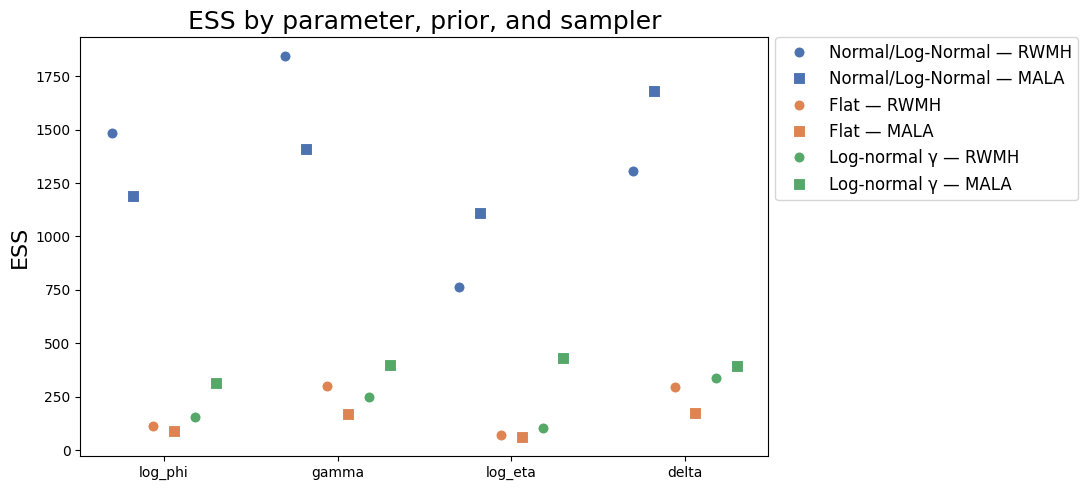

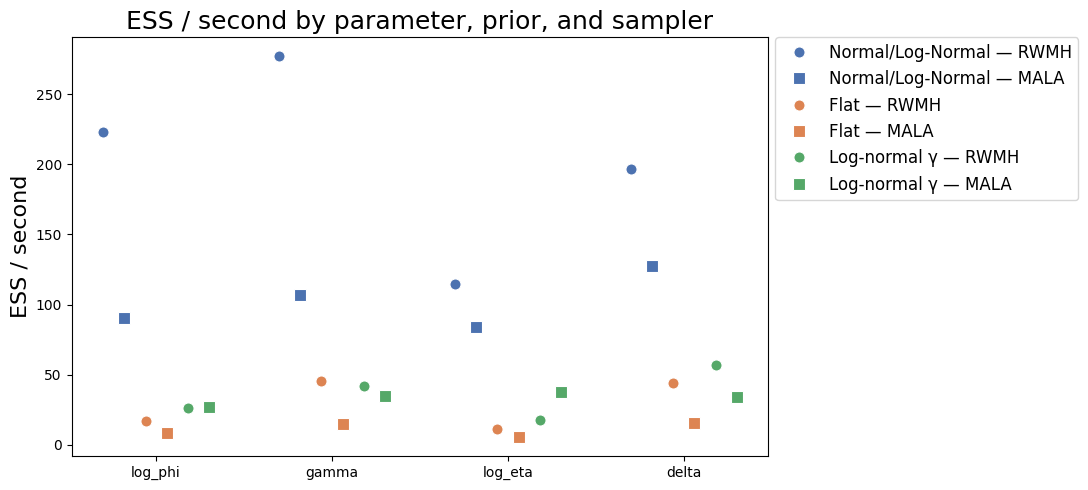

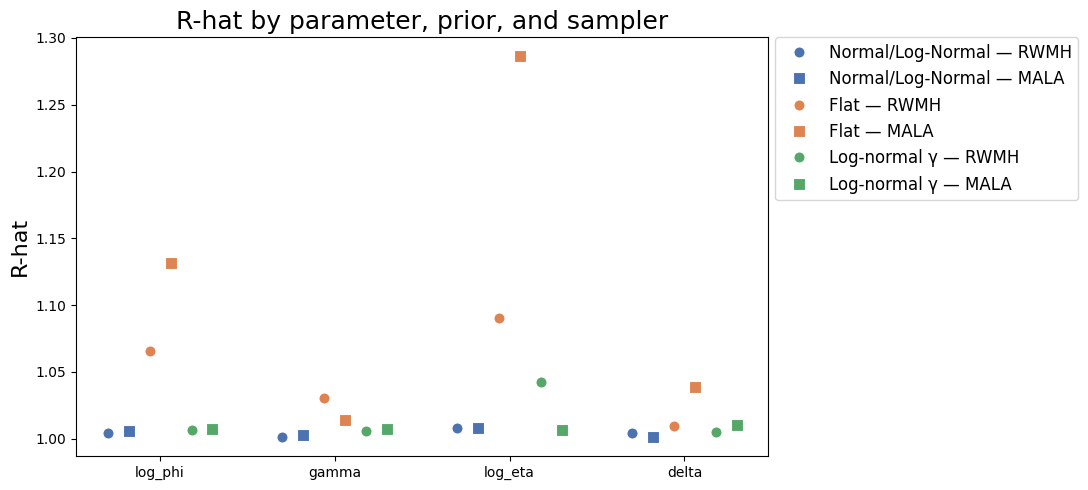

In [6]:
def plot_diagnostic(diag: str, data: dict):
    # infer parameter columns from first available df
    sample_df = data[diag][PRIORS[0]]
    param_cols = [c for c in sample_df.columns if c not in META_COLS]
    n_params = len(param_cols)

    x = np.arange(n_params)
    # spread points within each x position so they don't overlap
    n_series = len(PRIORS) * len(SAMPLERS)
    offsets = np.linspace(-0.3, 0.3, n_series)

    fig, ax = plt.subplots(figsize=(2.5 * n_params + 1, 5))

    series_idx = 0
    legend_handles = []
    for prior in PRIORS:
        for sampler in SAMPLERS:
            df = data[diag][prior]
            if sampler not in df.index:
                series_idx += 1
                continue
            row = df.loc[sampler, param_cols]
            color = PRIOR_COLORS[prior]
            marker = SAMPLER_MARKERS[sampler]
            offset = offsets[series_idx]

            h = ax.plot(
                x + offset,
                row.values,
                marker=marker,
                color=color,
                linestyle="none",
                markersize=8,
                markeredgewidth=0.8,
                markeredgecolor="white",
                label=f"{PRIOR_LABELS[prior]} — {sampler}",
            )
            legend_handles.append(h[0])
            series_idx += 1

    ax.set_xticks(x)
    ax.set_xticklabels(param_cols, fontsize=40)
    ax.set_ylabel(DIAG_LABELS[diag], fontsize=16)
    ax.set_title(f"{DIAG_LABELS[diag]} by parameter, prior, and sampler", fontsize=18)
    ax.tick_params(labelsize=10)

    ax.legend(fontsize=12, bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0)
    plt.tight_layout()
    if DIAG_LABELS[diag] == "R-hat":
        plt.savefig(f"Figures/{DIAG_LABELS[diag]}_diagnostics_cutoff.png", dpi = 600)


for diag in DIAGNOSTICS:
    plot_diagnostic(diag, data)